In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

<frozen importlib._bootstrap>:488: RuntimeWarning: The global interpreter lock (GIL) has been enabled to load module 'pandas._libs.pandas_parser', which has not declared that it can run safely without the GIL. To override this behavior and keep the GIL disabled (at your own risk), run with PYTHON_GIL=0 or -Xgil=0.


In [2]:
df = pd.read_csv("data.csv")
df.head()

,bedrooms,bathrooms,sqft,lot_size_acres,age_years,distance_city_center_km,crime_rate_index,school_rating,price
0,4.0,1.0,3816.0,0.61,31.0,13.58,1.06,4.0,1181818.01
1,5.0,1.0,4209.0,0.71,67.0,5.77,7.09,2.0,1281567.77
2,3.0,3.0,4319.0,0.93,17.0,4.38,3.52,9.0,1431253.97
3,5.0,2.0,902.0,0.79,42.0,16.85,0.17,9.0,686784.74
4,5.0,1.0,3391.0,0.10,34.0,27.17,4.09,2.0,998632.82


In [3]:
df.describe()

,bedrooms,bathrooms,sqft,lot_size_acres,age_years,distance_city_center_km,crime_rate_index,school_rating,price
count,979.000000,979.000000,979.000000,979.000000,979.000000,979.000000,979.000000,979.000000,9.790000e+02
mean,3.004086,1.980592,2673.442288,0.531491,40.437181,15.465148,4.987661,5.592441,9.247128e+05
std,1.430026,0.813128,1538.113197,0.278156,22.947056,8.349575,2.861660,2.898837,5.509074e+05
min,1.000000,1.000000,601.000000,0.050000,0.000000,1.000000,0.110000,1.000000,2.969574e+05
25%,2.000000,1.000000,1611.000000,0.290000,20.500000,8.230000,2.510000,3.000000,6.843445e+05
50%,3.000000,2.000000,2620.000000,0.550000,41.000000,15.630000,4.860000,6.000000,8.967084e+05
75%,4.000000,3.000000,3588.000000,0.770000,60.000000,22.525000,7.435000,8.000000,1.068378e+06
max,5.000000,3.000000,17800.000000,1.000000,79.000000,29.930000,9.990000,10.000000,7.560365e+06


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   bedrooms                 979 non-null    float64
 1   bathrooms                979 non-null    float64
 2   sqft                     979 non-null    float64
 3   lot_size_acres           979 non-null    float64
 4   age_years                979 non-null    float64
 5   distance_city_center_km  979 non-null    float64
 6   crime_rate_index         979 non-null    float64
 7   school_rating            979 non-null    float64
 8   price                    979 non-null    float64
dtypes: float64(9)
memory usage: 72.6 KB


In [5]:
df.isnull().sum()

bedrooms                   51
bathrooms                  51
sqft                       51
lot_size_acres             51
age_years                  51
distance_city_center_km    51
crime_rate_index           51
school_rating              51
price                      51
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

bedrooms                   0
bathrooms                  0
sqft                       0
lot_size_acres             0
age_years                  0
distance_city_center_km    0
crime_rate_index           0
school_rating              0
price                      0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(29)

In [9]:
df.drop_duplicates(inplace = True)
df.reset_index(drop = True, inplace = True)

In [10]:
df.duplicated().sum()

np.int64(0)

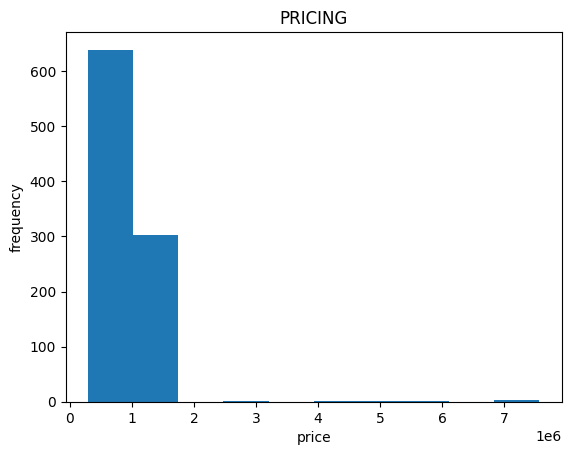

In [11]:
plt.hist(df['price'])
plt.xlabel('price')
plt.ylabel('frequency')
plt.title('PRICING')
plt.show()

In [12]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

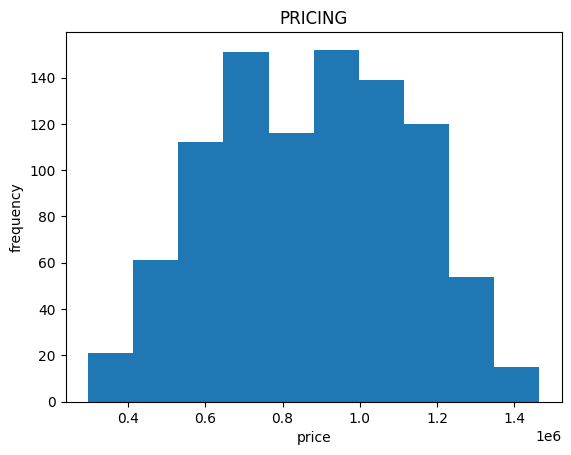

In [13]:
plt.hist(df['price'])
plt.xlabel('price')
plt.ylabel('frequency')
plt.title('PRICING')
plt.show()

In [14]:
x = df.drop(columns='price')
y = df['price']


In [15]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [16]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [17]:
regression = LinearRegression()

In [18]:
regression.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
mse = cross_val_score(regression, x_train, y_train, scoring="neg_mean_squared_error", cv=10)

In [20]:
np.mean(mse)

np.float64(-424636232.9672371)

In [21]:
reg_pred = regression.predict(x_test)

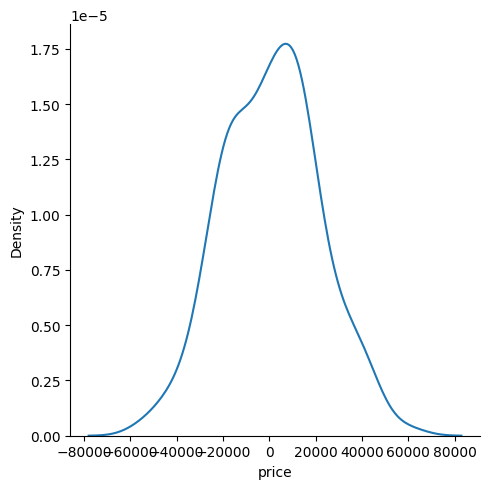

In [22]:
sns.displot(reg_pred-y_test,kind = 'kde')

In [23]:
r2 = r2_score(y_test, reg_pred)
print(r2)

0.992380007749356


In [24]:
new_house = [[4.0, 1.0, 3816.0, 0.61, 31.0, 13.58, 1.06, 4.0]]
new_house_scaled = scaler.transform(new_house)
predicted_price = regression.predict(new_house_scaled)
print(predicted_price)

[1149963.37979227]


d:\internship pro\ml-project\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
